BAHRAIN 24

In [210]:
import fastf1
import pandas as pd
import os
import numpy as np

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')

# Load the 2024 Bahrain Grand Prix
session = fastf1.get_session(2024, 'Bahrain', 'R')
session.load()

print("Session loaded!")
print(session)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Session loaded!
2024 Season Round 1: Bahrain Grand Prix - Race


In [211]:
laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 01:01:37.489000    VER            1 0 days 00:01:37.284000   
1 0 days 01:03:13.785000    VER            1 0 days 00:01:36.296000   
2 0 days 01:04:50.538000    VER            1 0 days 00:01:36.753000   
3 0 days 01:06:27.185000    VER            1 0 days 00:01:36.647000   
4 0 days 01:08:04.358000    VER            1 0 days 00:01:37.173000   
5 0 days 01:09:41.450000    VER            1 0 days 00:01:37.092000   
6 0 days 01:11:18.488000    VER            1 0 days 00:01:37.038000   

In [212]:
tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(57))

   Driver  LapNumber Compound  TyreLife                LapTime
0     VER        1.0     SOFT       4.0 0 days 00:01:37.284000
1     VER        2.0     SOFT       5.0 0 days 00:01:36.296000
2     VER        3.0     SOFT       6.0 0 days 00:01:36.753000
3     VER        4.0     SOFT       7.0 0 days 00:01:36.647000
4     VER        5.0     SOFT       8.0 0 days 00:01:37.173000
5     VER        6.0     SOFT       9.0 0 days 00:01:37.092000
6     VER        7.0     SOFT      10.0 0 days 00:01:37.038000
7     VER        8.0     SOFT      11.0 0 days 00:01:37.024000
8     VER        9.0     SOFT      12.0 0 days 00:01:37.229000
9     VER       10.0     SOFT      13.0 0 days 00:01:36.960000
10    VER       11.0     SOFT      14.0 0 days 00:01:37.085000
11    VER       12.0     SOFT      15.0 0 days 00:01:37.045000
12    VER       13.0     SOFT      16.0 0 days 00:01:37.030000
13    VER       14.0     SOFT      17.0 0 days 00:01:37.028000
14    VER       15.0     SOFT      18.0 0 days 00:01:37

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


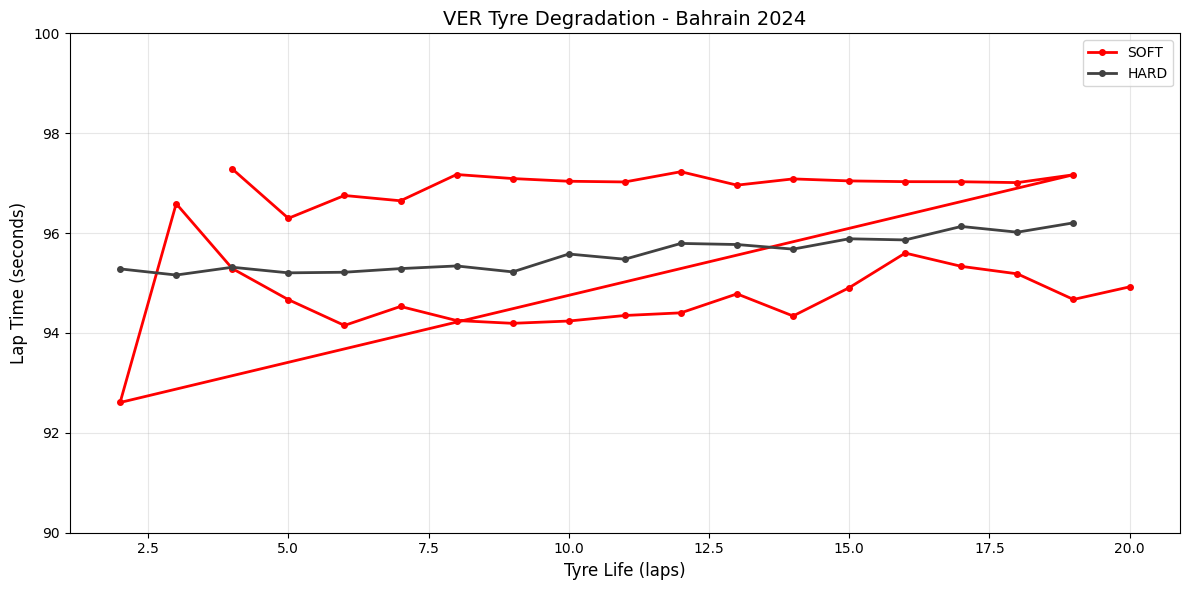

In [213]:
import matplotlib.pyplot as plt

ver = session.laps.pick_driver('VER').copy()
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ver_clean = ver[
    (ver['PitOutTime'].isna()) &   # not a pit out lap
    (ver['PitInTime'].isna()) &    # not a pit in lap
    (ver['LapTimeSeconds'] < 102) &
    (ver['LapTimeSeconds'] > 88)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': '#FFF200', 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = ver_clean[ver_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('VER Tyre Degradation - Bahrain 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(90, 100)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

MONACO 24

In [214]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')

# Load the 2024 Bahrain Grand Prix
session = fastf1.get_session(2024, 'Monaco', 'R')
session.load()

print("Session loaded!")
print(session)

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '14', '3', '77', '18', '2', '24', '31', '11', '27', '20']


Session loaded!
2024 Season Round 8: Monaco Grand Prix - Race


In [215]:
laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 01:36:02.319000    LEC           16 0 days 00:40:56.330000   
1 0 days 01:39:00.140000    LEC           16                    NaT   
2 0 days 01:40:24.764000    LEC           16 0 days 00:01:24.624000   
3 0 days 01:41:47.389000    LEC           16 0 days 00:01:22.625000   
4 0 days 01:43:09.184000    LEC           16 0 days 00:01:21.795000   
5 0 days 01:44:30.329000    LEC           16 0 days 00:01:21.145000   
6 0 days 01:45:51.309000    LEC           16 0 days 00:01:20.980000   

In [216]:
tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(77))

   Driver  LapNumber Compound  TyreLife                LapTime
0     LEC        1.0   MEDIUM       1.0 0 days 00:40:56.330000
2     LEC        3.0     HARD       2.0 0 days 00:01:24.624000
3     LEC        4.0     HARD       3.0 0 days 00:01:22.625000
4     LEC        5.0     HARD       4.0 0 days 00:01:21.795000
5     LEC        6.0     HARD       5.0 0 days 00:01:21.145000
..    ...        ...      ...       ...                    ...
73    LEC       74.0     HARD      73.0 0 days 00:01:16.105000
74    LEC       75.0     HARD      74.0 0 days 00:01:16.387000
75    LEC       76.0     HARD      75.0 0 days 00:01:16.808000
76    LEC       77.0     HARD      76.0 0 days 00:01:16.933000
77    LEC       78.0     HARD      77.0 0 days 00:01:18.636000

[77 rows x 5 columns]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


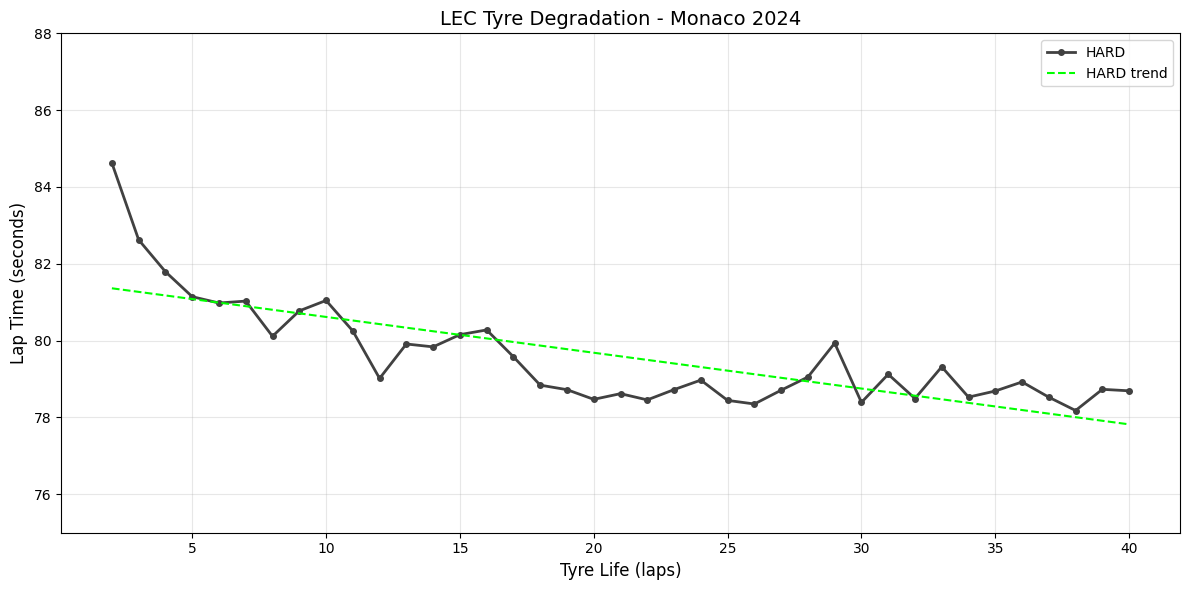

In [217]:
import matplotlib.pyplot as plt

lec = session.laps.pick_driver('LEC').copy()
lec['LapTimeSeconds'] = lec['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
lec_clean = lec[
    (lec['PitOutTime'].isna()) &   # not a pit out lap
    (lec['PitInTime'].isna()) &    # not a pit in lap
    (lec['LapTimeSeconds'] < 88) &
    (lec['LapTimeSeconds'] > 75)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': '#FFF200', 'HARD': "#414141"}

for compound in lec_clean['Compound'].unique():
    stint = lec_clean[lec_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

    x = stint['TyreLife'].values
    y = stint['LapTimeSeconds'].values
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        plt.plot(x, p(x),
                 color='#00FF00',
                 linewidth=1.5,
                 linestyle='--',
                 label=f'{compound} trend')

plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('LEC Tyre Degradation - Monaco 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(75, 88)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

JAPAN 24

In [218]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Japan', 'R')
session.load()

print("Session loaded!")
print(session)

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '4', '14', '63', '81', '44', '22', '27', '18', '20', '77', '31', '10', '2', '24', '3', '23']


Session loaded!
2024 Season Round 4: Japanese Grand Prix - Race


In [219]:
laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 01:04:51.506000    VER            1 0 days 00:02:10.735000   
1 0 days 01:33:22.630000    VER            1                    NaT   
2 0 days 01:36:15.449000    VER            1                    NaT   
3 0 days 01:37:51.921000    VER            1 0 days 00:01:36.472000   
4 0 days 01:39:28.358000    VER            1 0 days 00:01:36.437000   
5 0 days 01:41:05.213000    VER            1 0 days 00:01:36.855000   
6 0 days 01:42:42.183000    VER            1 0 days 00:01:36.970000   

In [220]:
tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(51))

   Driver  LapNumber Compound  TyreLife                LapTime
0     VER        1.0   MEDIUM       1.0 0 days 00:02:10.735000
3     VER        4.0   MEDIUM       4.0 0 days 00:01:36.472000
4     VER        5.0   MEDIUM       5.0 0 days 00:01:36.437000
5     VER        6.0   MEDIUM       6.0 0 days 00:01:36.855000
6     VER        7.0   MEDIUM       7.0 0 days 00:01:36.970000
7     VER        8.0   MEDIUM       8.0 0 days 00:01:37.329000
8     VER        9.0   MEDIUM       9.0 0 days 00:01:37.178000
9     VER       10.0   MEDIUM      10.0 0 days 00:01:37.590000
10    VER       11.0   MEDIUM      11.0 0 days 00:01:37.774000
11    VER       12.0   MEDIUM      12.0 0 days 00:01:37.753000
12    VER       13.0   MEDIUM      13.0 0 days 00:01:37.727000
13    VER       14.0   MEDIUM      14.0 0 days 00:01:37.910000
14    VER       15.0   MEDIUM      15.0 0 days 00:01:37.854000
15    VER       16.0   MEDIUM      16.0 0 days 00:01:40.272000
16    VER       17.0   MEDIUM       1.0 0 days 00:01:56

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


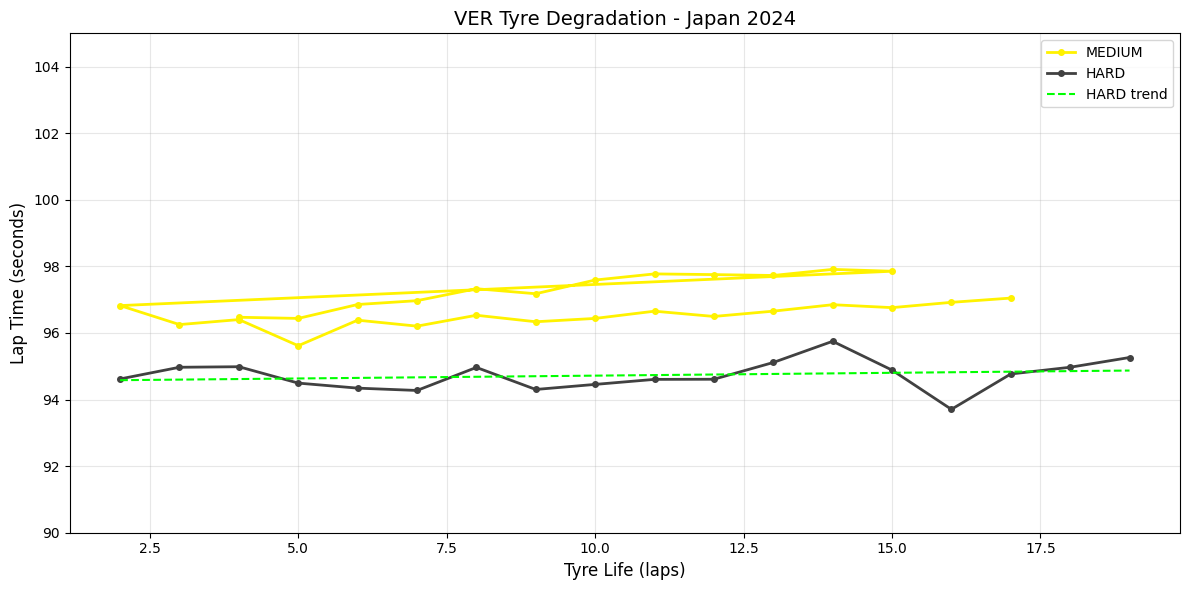

In [221]:
import matplotlib.pyplot as plt

ver = session.laps.pick_driver('VER').copy()
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ver_clean = ver[
    (ver['PitOutTime'].isna()) &   # not a pit out lap
    (ver['PitInTime'].isna()) &    # not a pit in lap
    (ver['LapTimeSeconds'] < 105) &
    (ver['LapTimeSeconds'] > 90)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = ver_clean[ver_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('VER Tyre Degradation - Japan 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(90, 105)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

ITALY 2024

In [222]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Italy', 'R')
session.load()

print("Session loaded!")
print(session)

events      WARNING 	Correcting user input 'Italy' to 'Italian Grand Prix'
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24'

Session loaded!
2024 Season Round 16: Italian Grand Prix - Race


In [223]:
laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:57:18.931000    LEC           16 0 days 00:01:28.179000   
1 0 days 00:58:44.327000    LEC           16 0 days 00:01:25.396000   
2 0 days 01:00:09.506000    LEC           16 0 days 00:01:25.179000   
3 0 days 01:01:34.316000    LEC           16 0 days 00:01:24.810000   
4 0 days 01:02:58.919000    LEC           16 0 days 00:01:24.603000   
5 0 days 01:04:23.582000    LEC           16 0 days 00:01:24.663000   
6 0 days 01:05:48.016000    LEC           16 0 days 00:01:24.434000   

In [224]:
tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(53))

   Driver  LapNumber Compound  TyreLife                LapTime
0     LEC        1.0   MEDIUM       1.0 0 days 00:01:28.179000
1     LEC        2.0   MEDIUM       2.0 0 days 00:01:25.396000
2     LEC        3.0   MEDIUM       3.0 0 days 00:01:25.179000
3     LEC        4.0   MEDIUM       4.0 0 days 00:01:24.810000
4     LEC        5.0   MEDIUM       5.0 0 days 00:01:24.603000
5     LEC        6.0   MEDIUM       6.0 0 days 00:01:24.663000
6     LEC        7.0   MEDIUM       7.0 0 days 00:01:24.434000
7     LEC        8.0   MEDIUM       8.0 0 days 00:01:24.569000
8     LEC        9.0   MEDIUM       9.0 0 days 00:01:24.362000
9     LEC       10.0   MEDIUM      10.0 0 days 00:01:24.432000
10    LEC       11.0   MEDIUM      11.0 0 days 00:01:24.846000
11    LEC       12.0   MEDIUM      12.0 0 days 00:01:24.916000
12    LEC       13.0   MEDIUM      13.0 0 days 00:01:25.529000
13    LEC       14.0   MEDIUM      14.0 0 days 00:01:25.606000
14    LEC       15.0   MEDIUM      15.0 0 days 00:01:30

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


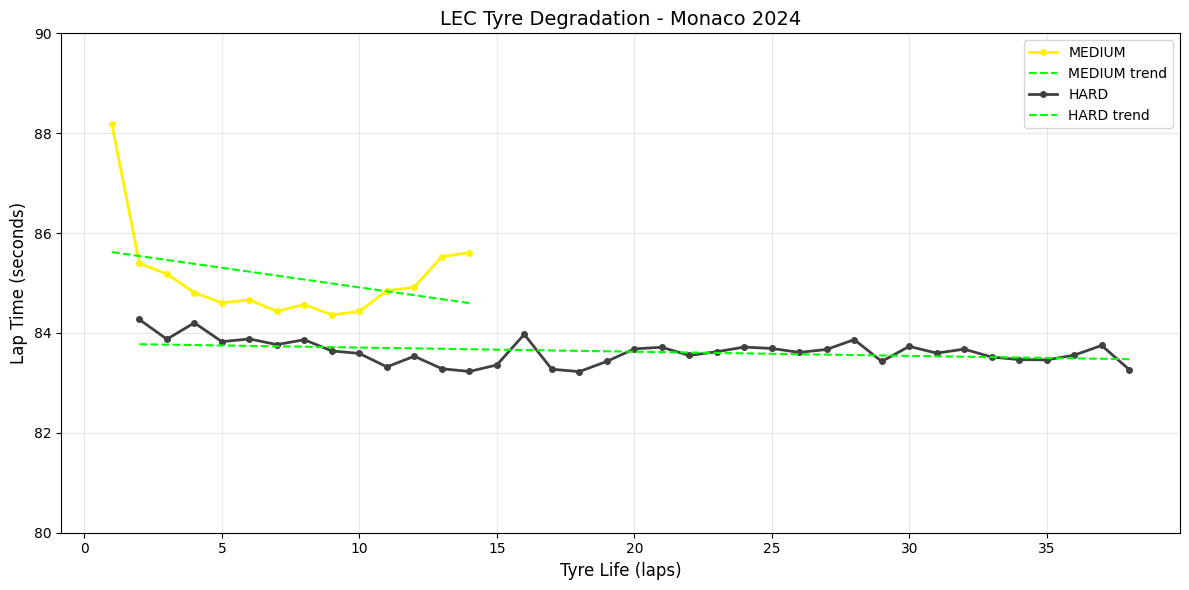

In [225]:
import matplotlib.pyplot as plt

lec = session.laps.pick_driver('LEC').copy()
lec['LapTimeSeconds'] = lec['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
lec_clean = lec[
    (lec['PitOutTime'].isna()) &   # not a pit out lap
    (lec['PitInTime'].isna()) &    # not a pit in lap
    (lec['LapTimeSeconds'] < 90) &
    (lec['LapTimeSeconds'] > 80)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': '#FFF200', 'HARD': "#414141"}

for compound in lec_clean['Compound'].unique():
    stint = lec_clean[lec_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

    x = stint['TyreLife'].values
    y = stint['LapTimeSeconds'].values
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        plt.plot(x, p(x),
                 color='#00FF00',
                 linewidth=1.5,
                 linestyle='--',
                 label=f'{compound} trend')

plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('LEC Tyre Degradation - Monaco 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(80, 90)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

JEDDAH 24

In [226]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Saudi Arabia', 'R')
session.load()

print("Session loaded!")
print(session)

core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']


Session loaded!
2024 Season Round 2: Saudi Arabian Grand Prix - Race


In [227]:
laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 01:01:19.630000    VER            1 0 days 00:01:35.505000   
1 0 days 01:02:53.835000    VER            1 0 days 00:01:34.205000   
2 0 days 01:04:27.878000    VER            1 0 days 00:01:34.043000   
3 0 days 01:06:01.632000    VER            1 0 days 00:01:33.754000   
4 0 days 01:07:35.587000    VER            1 0 days 00:01:33.955000   
5 0 days 01:09:09.263000    VER            1 0 days 00:01:33.676000   
6 0 days 01:11:12.182000    VER            1 0 days 00:02:02.919000   

In [228]:
tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(48))

   Driver  LapNumber Compound  TyreLife                LapTime
0     VER        1.0   MEDIUM       1.0 0 days 00:01:35.505000
1     VER        2.0   MEDIUM       2.0 0 days 00:01:34.205000
2     VER        3.0   MEDIUM       3.0 0 days 00:01:34.043000
3     VER        4.0   MEDIUM       4.0 0 days 00:01:33.754000
4     VER        5.0   MEDIUM       5.0 0 days 00:01:33.955000
5     VER        6.0   MEDIUM       6.0 0 days 00:01:33.676000
6     VER        7.0   MEDIUM       7.0 0 days 00:02:02.919000
9     VER       10.0     HARD       3.0 0 days 00:01:35.024000
10    VER       11.0     HARD       4.0 0 days 00:01:33.610000
11    VER       12.0     HARD       5.0 0 days 00:01:33.321000
12    VER       13.0     HARD       6.0 0 days 00:01:33.144000
13    VER       14.0     HARD       7.0 0 days 00:01:33.194000
14    VER       15.0     HARD       8.0 0 days 00:01:33.512000
15    VER       16.0     HARD       9.0 0 days 00:01:33.192000
16    VER       17.0     HARD      10.0 0 days 00:01:33

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


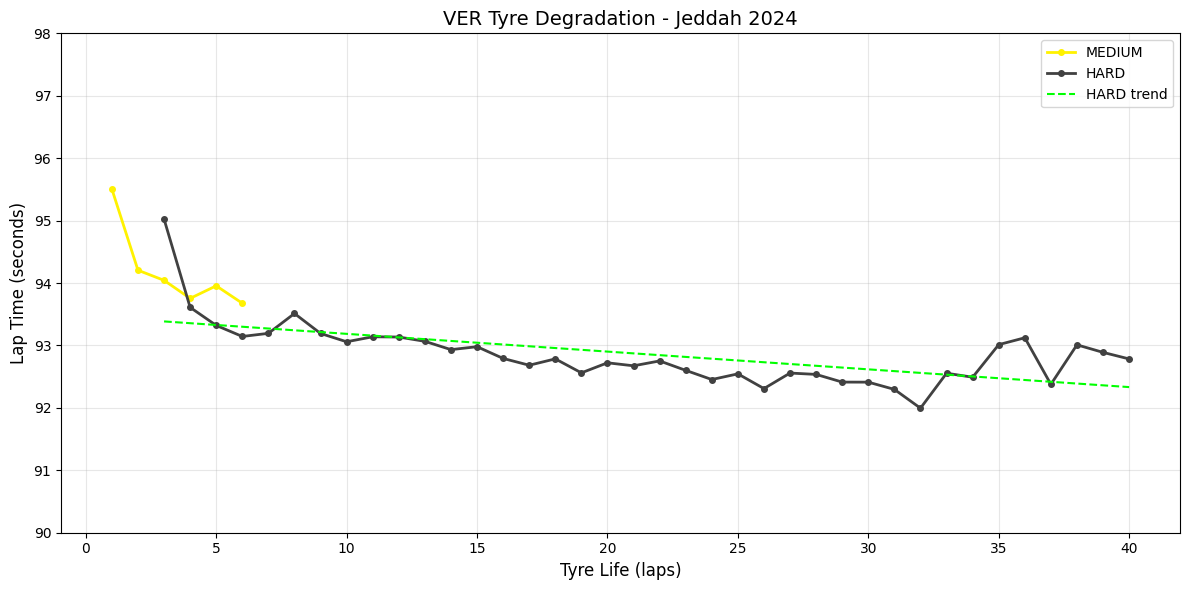

In [229]:
import matplotlib.pyplot as plt

ver = session.laps.pick_driver('VER').copy()
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ver_clean = ver[
    (ver['PitOutTime'].isna()) &   # not a pit out lap
    (ver['PitInTime'].isna()) &    # not a pit in lap
    (ver['LapTimeSeconds'] < 98) &
    (ver['LapTimeSeconds'] > 90)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = ver_clean[ver_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('VER Tyre Degradation - Jeddah 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(90, 98)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

GREAT BRITAIN 2024

core           INFO 	Loading data for British Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '16', '77', '31', '11', '24', '63', '10']


Session loaded!
2024 Season Round 12: British Grand Prix - Race
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:59:51.778000    HAM           44 0 days 00:01:36.034000   
1 0 days 01:01:23.198000    HAM           44 0 days 00:01:31.420000   
2 0 days 01:02:54.914000    HAM           44 0 days 00:01:31.716000   
3 0 days 01:04:26.902000    HAM           44 0 days 00:01:31.988000   
4 0 days 01:05:58.579000    HAM           44 0 days 00:01:31.677000   
5 0 days 01:07:30.325000    HAM           44 0 days 00:01:31.746000   
6     

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


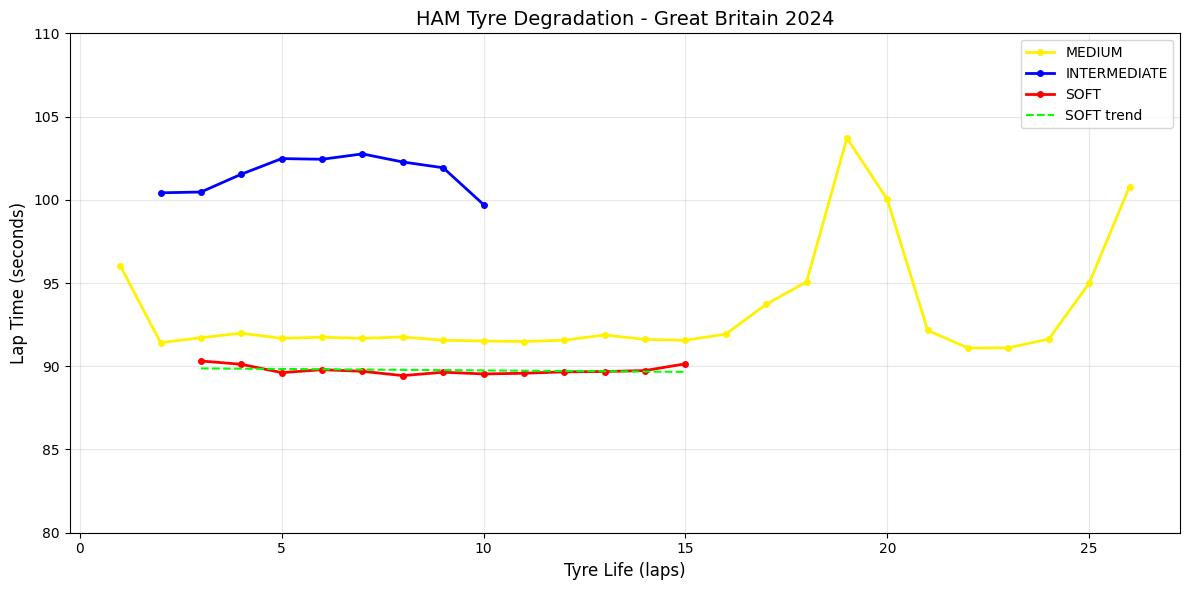

In [230]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'British', 'R')
session.load()

print("Session loaded!")
print(session)

laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows


tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(53))

import matplotlib.pyplot as plt

ham = session.laps.pick_driver('HAM').copy()
ham['LapTimeSeconds'] = ham['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ham_clean = ham[
    (ham['PitOutTime'].isna()) &   # not a pit out lap
    (ham['PitInTime'].isna()) &    # not a pit in lap
    (ham['LapTimeSeconds'] < 110) &
    (ham['LapTimeSeconds'] > 80)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ham_clean['Compound'].unique():
    stint = ham_clean[ham_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('HAM Tyre Degradation - Great Britain 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(80, 110)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

Singapore 2024

core           INFO 	Loading data for Singapore Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '81', '63', '16', '44', '55', '14', '27', '11', '43', '22', '31', '18', '24', '77', '10', '3', '20', '23']


Session loaded!
2024 Season Round 18: Singapore Grand Prix - Race
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:58:41.675000    NOR            4 0 days 00:01:40.424000   
1 0 days 01:00:20.155000    NOR            4 0 days 00:01:38.480000   
2 0 days 01:01:58.561000    NOR            4 0 days 00:01:38.406000   
3 0 days 01:03:37.007000    NOR            4 0 days 00:01:38.446000   
4 0 days 01:05:14.945000    NOR            4 0 days 00:01:37.938000   
5 0 days 01:06:52.788000    NOR            4 0 days 00:01:37.843000   
6 0 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


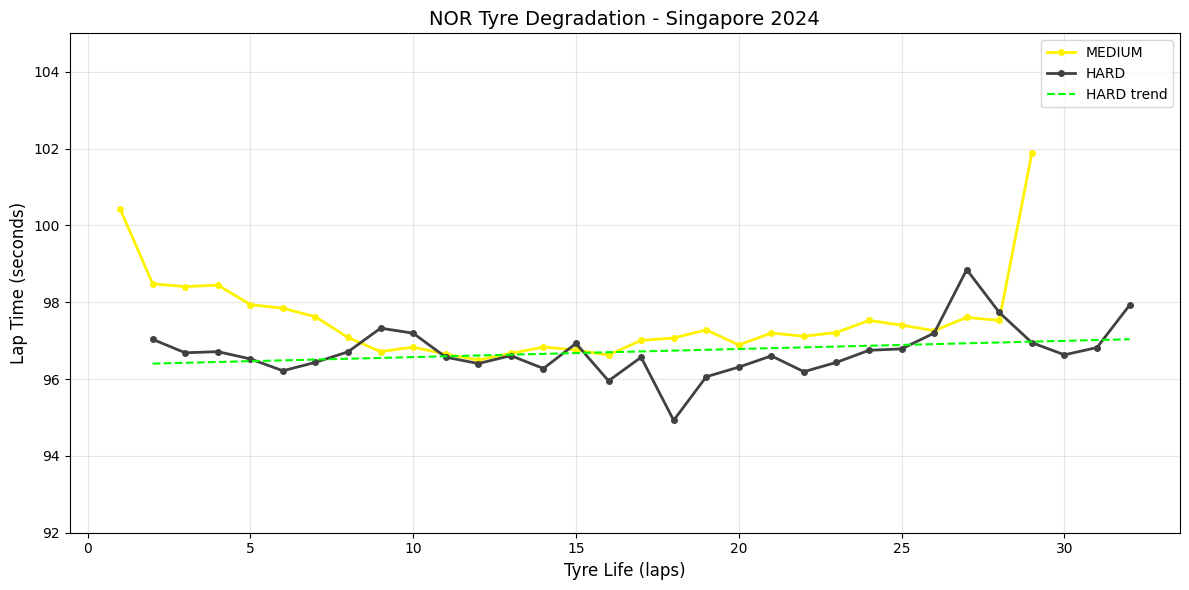

In [231]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Singapore', 'R')
session.load()

print("Session loaded!")
print(session)

laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows


tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(53))

import matplotlib.pyplot as plt

nor = session.laps.pick_driver('NOR').copy()
nor['LapTimeSeconds'] = nor['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
nor_clean = nor[
    (nor['PitOutTime'].isna()) &   # not a pit out lap
    (nor['PitInTime'].isna()) &    # not a pit in lap
    (nor['LapTimeSeconds'] < 105) &
    (nor['LapTimeSeconds'] > 92)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in nor_clean['Compound'].unique():
    stint = nor_clean[nor_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('NOR Tyre Degradation - Singapore 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(92, 105)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

Belgium 2024

core           INFO 	Loading data for Belgian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '14'
core        WARNING 	Fixed incorrect tyre stint information for driver '3'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core        WARNING 	Fixed incorrect tyre stint information for driver '22'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '81', '16', '1', '4', '55', '11', '14', '31', '3', '1

Session loaded!
2024 Season Round 14: Belgian Grand Prix - Race
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:57:07.735000    HAM           44 0 days 00:01:52.700000   
1 0 days 00:58:57.584000    HAM           44 0 days 00:01:49.849000   
2 0 days 01:00:46.693000    HAM           44 0 days 00:01:49.109000   
3 0 days 01:02:36.501000    HAM           44 0 days 00:01:49.808000   
4 0 days 01:04:25.877000    HAM           44 0 days 00:01:49.376000   
5 0 days 01:06:15.277000    HAM           44 0 days 00:01:49.400000   
6 0 da

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


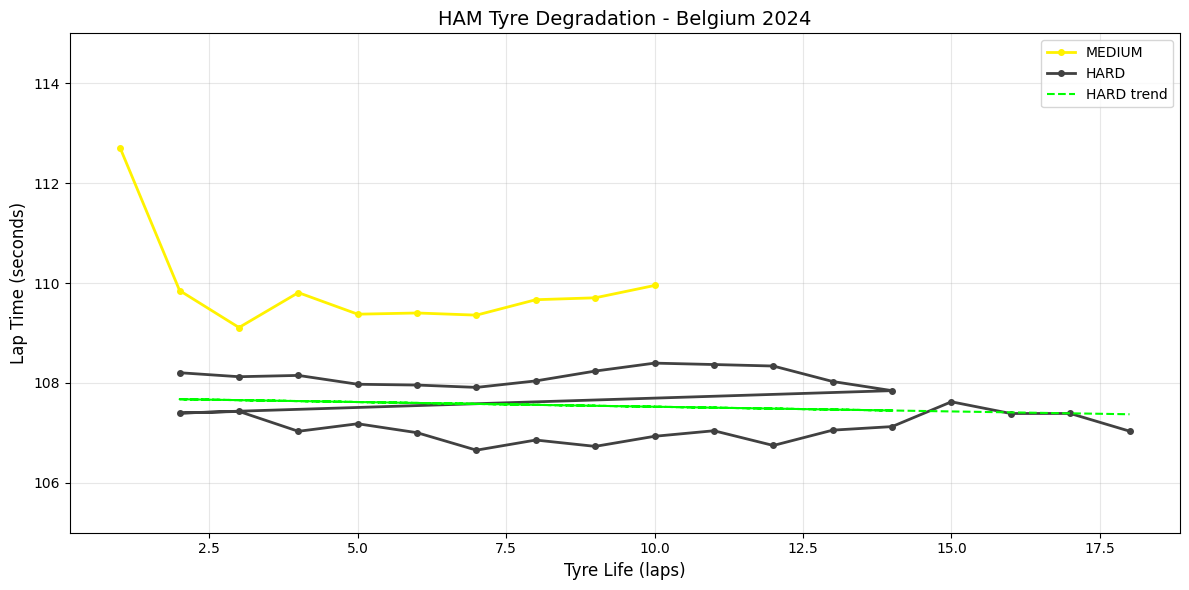

In [232]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Belgium', 'R')
session.load()

print("Session loaded!")
print(session)

laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows


tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(44))

import matplotlib.pyplot as plt

ham = session.laps.pick_driver('HAM').copy()
ham['LapTimeSeconds'] = ham['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ham_clean = ham[
    (ham['PitOutTime'].isna()) &   # not a pit out lap
    (ham['PitInTime'].isna()) &    # not a pit in lap
    (ham['LapTimeSeconds'] < 115) &
    (ham['LapTimeSeconds'] > 105)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ham_clean['Compound'].unique():
    stint = ham_clean[ham_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('HAM Tyre Degradation - Belgium 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(105, 115)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

SPAIN 2024

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 1 completed the race distance 00:00.015000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '44', '63', '16', '55', '81', '11', '10', '31', '27', '14

Session loaded!
2024 Season Round 10: Spanish Grand Prix - Race
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:58:20.507000    VER            1 0 days 00:01:23.186000   
1 0 days 00:59:40.378000    VER            1 0 days 00:01:19.871000   
2 0 days 01:00:59.742000    VER            1 0 days 00:01:19.364000   
3 0 days 01:02:20.508000    VER            1 0 days 00:01:20.766000   
4 0 days 01:03:41.335000    VER            1 0 days 00:01:20.827000   
5 0 days 01:05:02.211000    VER            1 0 days 00:01:20.876000   
6 0 da

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


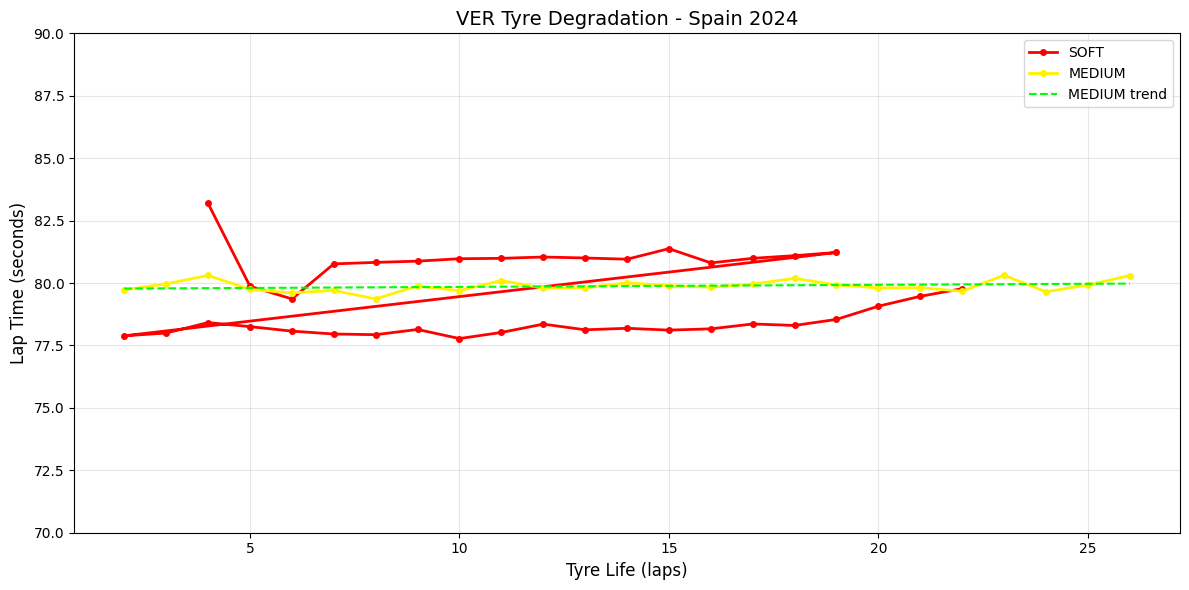

In [233]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Spain', 'R')
session.load()

print("Session loaded!")
print(session)

laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows


tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(57))

import matplotlib.pyplot as plt

ver = session.laps.pick_driver('VER').copy()
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ver_clean = ver[
    (ver['PitOutTime'].isna()) &   # not a pit out lap
    (ver['PitInTime'].isna()) &    # not a pit in lap
    (ver['LapTimeSeconds'] < 90) &
    (ver['LapTimeSeconds'] > 70)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = ver_clean[ver_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('VER Tyre Degradation - Spain 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(70, 90)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

CANADA 2024

core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '63', '44', '81', '14', '18', '3', '10', '31', '27', '20', '77', '22', '24', '55', '23', '11', '16', '2']


Session loaded!
2024 Season Round 9: Canadian Grand Prix - Race
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:05:50.866000    VER            1 0 days 00:01:44.993000   
1 0 days 00:07:28.538000    VER            1 0 days 00:01:37.672000   
2 0 days 00:09:04.981000    VER            1 0 days 00:01:36.443000   
3 0 days 00:10:40.086000    VER            1 0 days 00:01:35.105000   
4 0 days 00:12:13.945000    VER            1 0 days 00:01:33.859000   
5 0 days 00:13:46.579000    VER            1 0 days 00:01:32.634000   
6 0 da

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


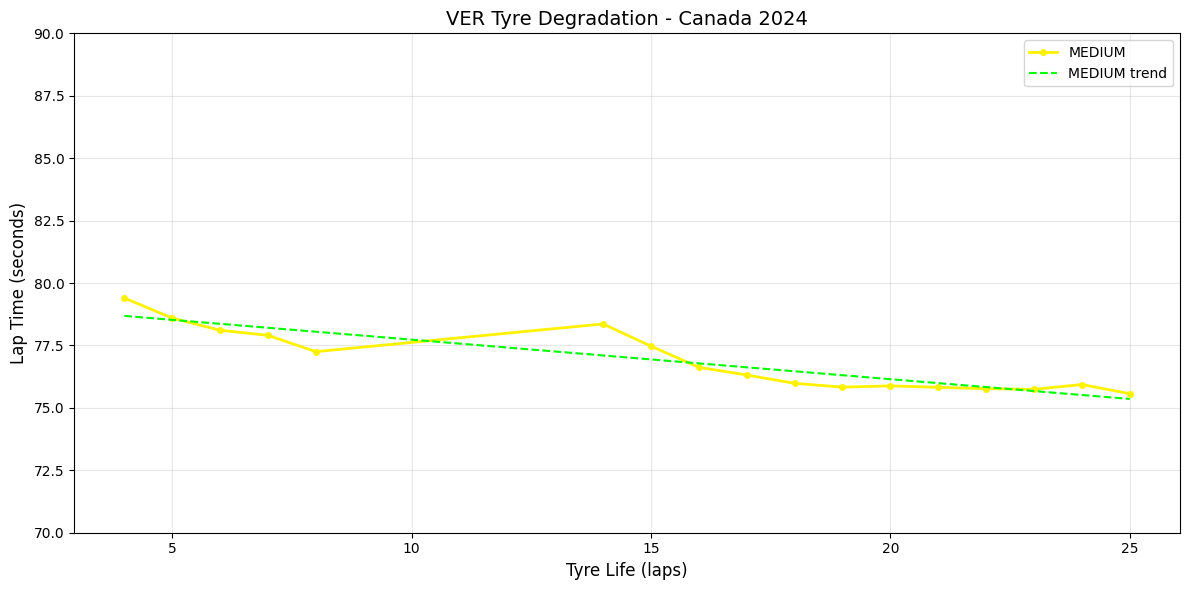

In [234]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Canada', 'R')
session.load()

print("Session loaded!")
print(session)

laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows


tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(64))

import matplotlib.pyplot as plt

ver = session.laps.pick_driver('VER').copy()
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ver_clean = ver[
    (ver['PitOutTime'].isna()) &   # not a pit out lap
    (ver['PitInTime'].isna()) &    # not a pit in lap
    (ver['LapTimeSeconds'] < 80) &
    (ver['LapTimeSeconds'] > 67)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = ver_clean[ver_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('VER Tyre Degradation - Canada 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(70, 90)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

Hungary 2024

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '44', '16', '1', '55', '11', '63', '22', '18', '14', '3', '27', '23', '20', '77', '2', '31', '24', '10']


Session loaded!
2024 Season Round 13: Hungarian Grand Prix - Race
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:56:31.948000    PIA           81 0 days 00:01:26.746000   
1 0 days 00:57:55.986000    PIA           81 0 days 00:01:24.038000   
2 0 days 00:59:20.387000    PIA           81 0 days 00:01:24.401000   
3 0 days 01:00:44.502000    PIA           81 0 days 00:01:24.115000   
4 0 days 01:02:08.298000    PIA           81 0 days 00:01:23.796000   
5 0 days 01:03:32.144000    PIA           81 0 days 00:01:23.846000   
6 0 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


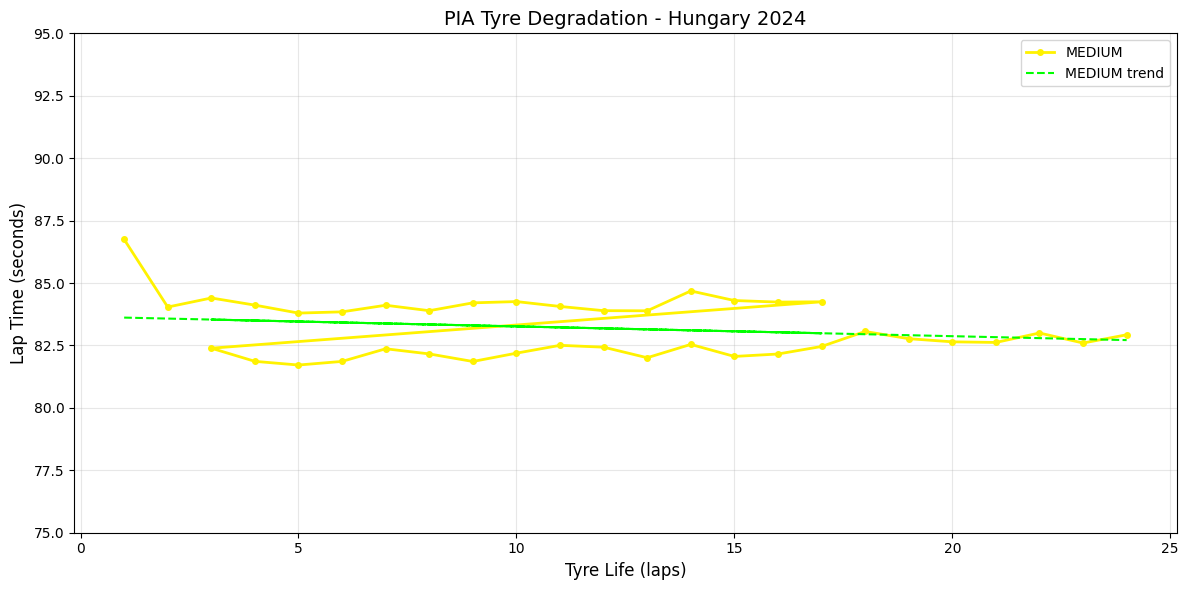

In [235]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Hungary', 'R')
session.load()

print("Session loaded!")
print(session)

laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows


tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(57))

import matplotlib.pyplot as plt

pia = session.laps.pick_driver('PIA').copy()
pia['LapTimeSeconds'] = pia['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
pia_clean = pia[
    (pia['PitOutTime'].isna()) &   # not a pit out lap
    (pia['PitInTime'].isna()) &    # not a pit in lap
    (pia['LapTimeSeconds'] < 95) &
    (pia['LapTimeSeconds'] > 75)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = pia_clean[pia_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('PIA Tyre Degradation - Hungary 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(75, 95)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

VEGAS 2024

core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 63: Lap timing integrity check failed for 2 lap(s)
core        WARNING 	Driver 44: Lap timing integrity check failed for 1 lap(s)
core        WARNING 	Driver 55: Lap timing integrity check failed for 1 lap(s)
core        WARNING 	Driver 16: Lap timing integrity check failed for 2 lap(s)
core        WARNING 	Driver  1: Lap timing integrity check failed for 1 lap(s)
core        WARNING 	Driver  4: Lap timing integrity check failed for 1

Session loaded!
2024 Season Round 22: Las Vegas Grand Prix - Race
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:58:10.045000    RUS           63 0 days 00:01:43.267000   
1 0 days 00:59:49.122000    RUS           63 0 days 00:01:39.077000   
2 0 days 01:01:27.986000    RUS           63 0 days 00:01:38.864000   
3 0 days 01:03:06.734000    RUS           63 0 days 00:01:38.748000   
4 0 days 01:04:44.870000    RUS           63 0 days 00:01:38.136000   
5 0 days 01:06:23.200000    RUS           63 0 days 00:01:38.330000   
6 0 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


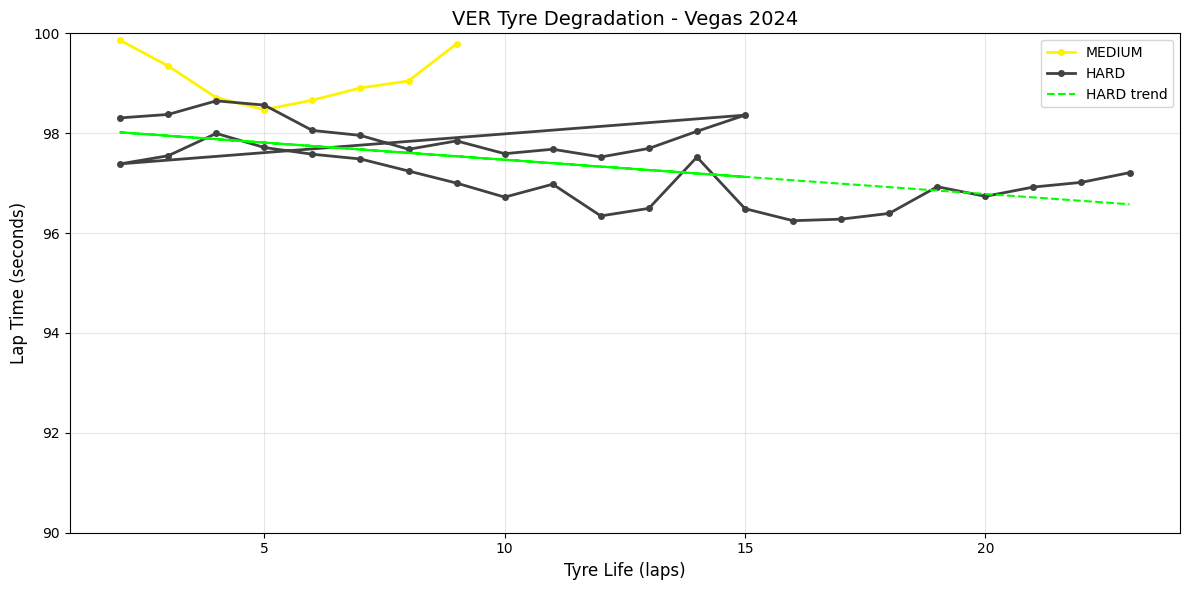

In [236]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'Las Vegas', 'R')
session.load()

print("Session loaded!")
print(session)

laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows


tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(57))

import matplotlib.pyplot as plt

ver = session.laps.pick_driver('VER').copy()
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ver_clean = ver[
    (ver['PitOutTime'].isna()) &   # not a pit out lap
    (ver['PitInTime'].isna()) &    # not a pit in lap
    (ver['LapTimeSeconds'] < 100) &
    (ver['LapTimeSeconds'] > 90)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = ver_clean[ver_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('VER Tyre Degradation - Vegas 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(90, 100)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

CHINA 2024

core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 1 completed the race distance 00:08.313000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '11', '16', '55', '63', '14', '81', '44', '27', '31', '23

Session loaded!
2024 Season Round 5: Chinese Grand Prix - Race
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:56:59.963000    VER            1 0 days 00:01:41.528000   
1 0 days 00:58:40.066000    VER            1 0 days 00:01:40.103000   
2 0 days 01:00:20.560000    VER            1 0 days 00:01:40.494000   
3 0 days 01:02:01.133000    VER            1 0 days 00:01:40.573000   
4 0 days 01:03:42.052000    VER            1 0 days 00:01:40.919000   
5 0 days 01:05:23.199000    VER            1 0 days 00:01:41.147000   
6 0 day

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


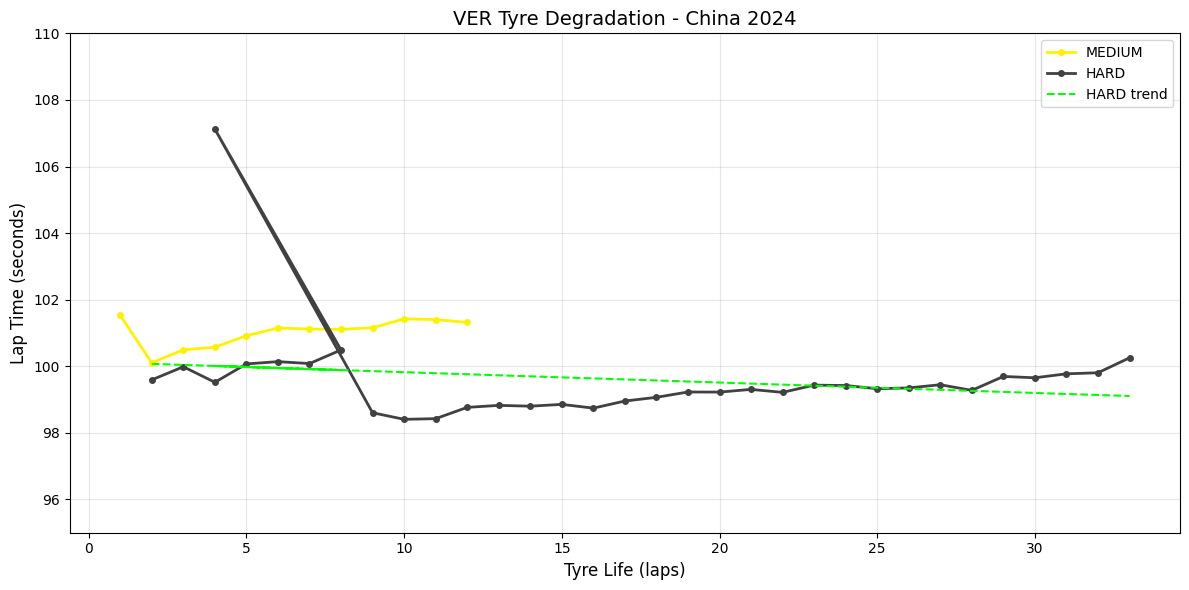

In [237]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2024, 'China', 'R')
session.load()

print("Session loaded!")
print(session)

laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows


tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(57))

import matplotlib.pyplot as plt

ver = session.laps.pick_driver('VER').copy()
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ver_clean = ver[
    (ver['PitOutTime'].isna()) &   # not a pit out lap
    (ver['PitInTime'].isna()) &    # not a pit in lap
    (ver['LapTimeSeconds'] < 110) &
    (ver['LapTimeSeconds'] > 95)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': "#FFF200", 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = ver_clean[ver_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')
        
plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('VER Tyre Degradation - China 2024', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(95, 110)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

2023

AUSTRALIA 2023


In [238]:
import fastf1
import pandas as pd
import os

# Create the cache folder if it doesn't exist, then enable it
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')


session = fastf1.get_session(2023, 'Australia', 'R')
session.load()

print("Session loaded!")
print(session)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '14', '18', '11', '4', '27', '81', '24', '22', '77', '55', '10', '31', '21', '2', '20', '63', '23', '16']


Session loaded!
2023 Season Round 3: Australian Grand Prix - Race


In [239]:
laps = session.laps
print(laps.columns.tolist()) # See all data columns
print(laps.head(10)) # See first 10 rows

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
                    Time Driver DriverNumber                LapTime  \
0 0 days 01:03:58.671000    VER            1 0 days 00:01:41.571000   
1 0 days 01:06:10.776000    VER            1 0 days 00:02:12.105000   
2 0 days 01:08:21.433000    VER            1 0 days 00:02:10.657000   
3 0 days 01:09:44.824000    VER            1 0 days 00:01:23.391000   
4 0 days 01:11:07.928000    VER            1 0 days 00:01:23.104000   
5 0 days 01:12:30.771000    VER            1 0 days 00:01:22.843000   
6 0 days 01:14:05.841000    VER            1 0 days 00:01:35.070000   

In [240]:
tyre_data = laps[['Driver', 'LapNumber', 'Compound',
'TyreLife', 'LapTime']].dropna()
print(tyre_data.head(58))

   Driver  LapNumber Compound  TyreLife                LapTime
0     VER        1.0   MEDIUM       1.0 0 days 00:01:41.571000
1     VER        2.0   MEDIUM       2.0 0 days 00:02:12.105000
2     VER        3.0   MEDIUM       3.0 0 days 00:02:10.657000
3     VER        4.0   MEDIUM       4.0 0 days 00:01:23.391000
4     VER        5.0   MEDIUM       5.0 0 days 00:01:23.104000
5     VER        6.0   MEDIUM       6.0 0 days 00:01:22.843000
6     VER        7.0   MEDIUM       7.0 0 days 00:01:35.070000
9     VER       10.0     HARD       2.0 0 days 00:01:27.827000
10    VER       11.0     HARD       3.0 0 days 00:01:23.460000
11    VER       12.0     HARD       4.0 0 days 00:01:21.994000
12    VER       13.0     HARD       5.0 0 days 00:01:23.286000
13    VER       14.0     HARD       6.0 0 days 00:01:22.869000
14    VER       15.0     HARD       7.0 0 days 00:01:22.817000
15    VER       16.0     HARD       8.0 0 days 00:01:22.599000
16    VER       17.0     HARD       9.0 0 days 00:01:22

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


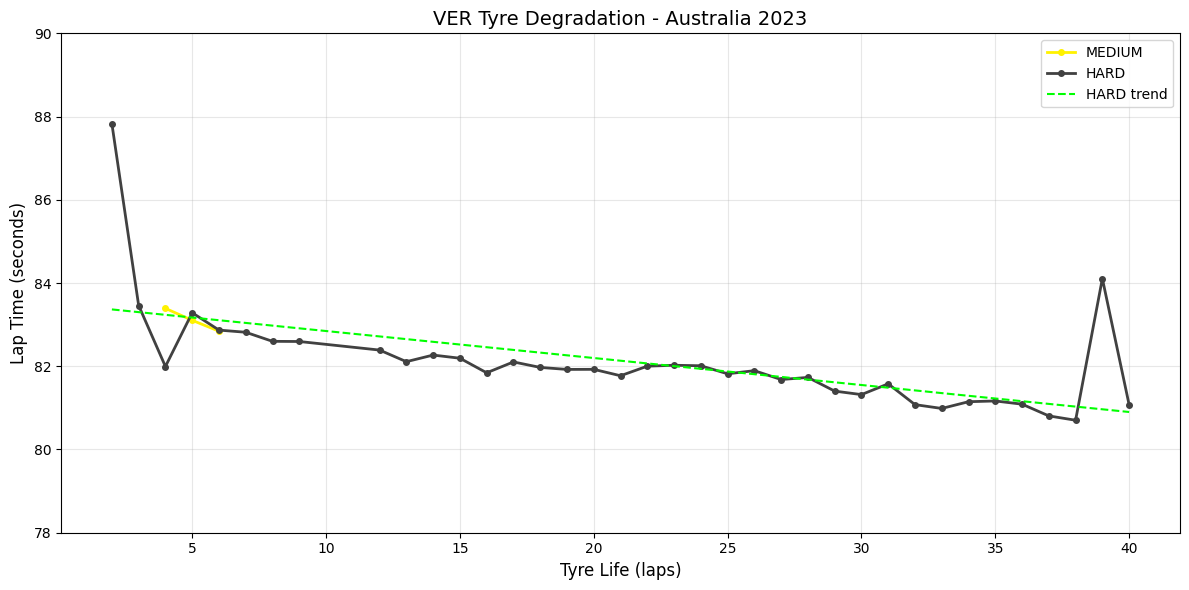

In [241]:
import matplotlib.pyplot as plt

ver = session.laps.pick_driver('VER').copy()
ver['LapTimeSeconds'] = ver['LapTime'].dt.total_seconds()

# Remove pit out laps, pit in laps, and any lap over 102s (slow/SC laps)
ver_clean = ver[
    (ver['PitOutTime'].isna()) &   # not a pit out lap
    (ver['PitInTime'].isna()) &    # not a pit in lap
    (ver['LapTimeSeconds'] < 95) &
    (ver['LapTimeSeconds'] > 80)   # remove any clearly abnormal laps
]

plt.figure(figsize=(12, 6))

colors = {'SOFT': '#FF0000', 'MEDIUM': '#FFF200', 'HARD': "#414141"}

for compound in ver_clean['Compound'].unique():
    stint = ver_clean[ver_clean['Compound'] == compound]
    # Only plot if tyre life goes up to 40 laps max
    stint = stint[stint['TyreLife'] <= 40]
    plt.plot(stint['TyreLife'], stint['LapTimeSeconds'],
             label=compound,
             color=colors.get(compound, 'blue'),
             marker='o', markersize=4, linewidth=2)

x = stint['TyreLife'].values
y = stint['LapTimeSeconds'].values
if len(x) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x),
        color='#00FF00',
        linewidth=1.5,
        linestyle='--',
        label=f'{compound} trend')

plt.xlabel('Tyre Life (laps)', fontsize=12)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.title('VER Tyre Degradation - Australia 2023', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(78, 90)  # Zoom the y-axis to the relevant range
plt.tight_layout()
plt.show()

In [242]:
import fastf1
import pandas as pd
import os

os.makedirs('Data/cache', exist_ok=True)
fastf1.Cache.enable_cache('Data/cache')

races_to_load = [
    (2024, 'Bahrain Grand Prix'),
    (2024, 'Monaco Grand Prix'),
    (2024, 'Japanese Grand Prix'),
    (2024, 'British Grand Prix'),
    (2024, 'Italian Grand Prix'),
    (2024, 'Saudi Arabian Grand Prix'),
    (2024, 'Singapore Grand Prix'),
    (2024, 'Belgian Grand Prix'),
    (2024, 'Spanish Grand Prix'),
    (2024, 'Canadian Grand Prix'),
    (2024, 'Hungarian Grand Prix'),
    (2024, 'Las Vegas Grand Prix'),
    (2024, 'Chinese Grand Prix'),
    (2023, 'Australian Grand Prix'),
]

all_laps = []

for year, race in races_to_load:
    try:
        session = fastf1.get_session(year, race, 'R')
        session.load()
        print(f"✅ Loaded: {year} {race} → {session.event['EventName']}")

        top5 = session.results.head(5)['Abbreviation'].tolist()

        for driver in top5:
            laps_df = session.laps.pick_driver(driver).copy()
            laps_df['Race'] = session.event['EventName']  # use official name
            laps_df['Year'] = year
            laps_df['Driver'] = driver
            all_laps.append(laps_df)

    except Exception as e:
        print(f"❌ Failed: {year} {race} — {e}")

combined = pd.concat(all_laps, ignore_index=True)
combined.to_csv('Data/f1_laps_combined.csv', index=False)
print(f"\nSaved! Total laps: {len(combined)}")
print("\nRaces in dataset:")
print(combined['Race'].unique())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3

✅ Loaded: 2024 Bahrain Grand Prix → Bahrain Grand Prix


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '14', '3', '77', '18', '2', '24', '31', '11', '27', '20']
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Library/Frameworks/Python.framework/Versions/

✅ Loaded: 2024 Monaco Grand Prix → Monaco Grand Prix


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '4', '14', '63', '81', '44', '22', '27', '18', '20', '77', '31', '10', '2', '24', '3', '23']
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Library/Frameworks/Python.framework/Versions/

...

✅ Loaded: 2024 Las Vegas Grand Prix → Las Vegas Grand Prix


core        WARNING 	Driver 1 completed the race distance 00:08.313000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '11', '16', '55', '63', '14', '81', '44', '27', '31', '23', '10', '24', '18', '20', '2', '3', '22', '77']
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.


✅ Loaded: 2024 Chinese Grand Prix → Chinese Grand Prix


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '14', '18', '11', '4', '27', '81', '24', '22', '77', '55', '10', '31', '21', '2', '20', '63', '23', '16']
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Library/Frameworks/Python.framework/Versions

✅ Loaded: 2023 Australian Grand Prix → Australian Grand Prix

Saved! Total laps: 4095

Races in dataset:
['Bahrain Grand Prix' 'Monaco Grand Prix' 'Japanese Grand Prix'
 'British Grand Prix' 'Italian Grand Prix' 'Saudi Arabian Grand Prix'
 'Singapore Grand Prix' 'Belgian Grand Prix' 'Spanish Grand Prix'
 'Canadian Grand Prix' 'Hungarian Grand Prix' 'Las Vegas Grand Prix'
 'Chinese Grand Prix' 'Australian Grand Prix']


In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import json

df = pd.read_csv('/Users/vihaan/Desktop/f1-strategy-ai/Data/f1_laps_combined.csv')
df['LapTime'] = pd.to_timedelta(df['LapTime']).dt.total_seconds()
df = df.dropna(subset=['LapTime', 'Compound', 'TyreLife', 'Race'])

# Remove physically impossible laps
df = df[df['LapTime'] > 55]
df = df[df['LapTime'] < 200]  # tighter upper limit to catch SC laps

# ── Circuit bounds from data ──────────────────────────────────────────────
print("=" * 60)
print("CIRCUIT BOUNDS")
print("=" * 60)

circuit_bounds = {}
for race, group in df.groupby('Race'):
    # Use tighter percentiles to exclude SC laps
    q02 = group['LapTime'].quantile(0.02)
    q90 = group['LapTime'].quantile(0.90)
    low  = round(q02 * 0.98, 1)
    high = round(q90 * 1.02, 1)
    circuit_bounds[race] = (low, high)
    print(f"'{race}': ({low}, {high}),")

# ── Clean data using tight bounds ─────────────────────────────────────────
filtered = []
for race, group in df.groupby('Race'):
    low, high = circuit_bounds[race]
    clean = group[(group['LapTime'] > low) & (group['LapTime'] < high)]
    filtered.append(clean)

df_clean = pd.concat(filtered, ignore_index=True)

# ── Degradation rates ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TYRE DEGRADATION RATES (s/lap)")
print("=" * 60)

# Global fallback rates (fuel-corrected estimates)
global_fallback = {'SOFT': 0.04, 'MEDIUM': 0.025, 'HARD': 0.012}
compounds = ['SOFT', 'MEDIUM', 'HARD']
deg_export = {}

print(f"\n{'Race':<32} {'SOFT':>8} {'MEDIUM':>8} {'HARD':>8}")
print("-" * 60)

for race in sorted(df_clean['Race'].unique()):
    race_data = df_clean[df_clean['Race'] == race]
    deg_export[race] = {}
    row_vals = []

    for compound in compounds:
        compound_data = race_data[
            (race_data['Compound'] == compound) &
            (race_data['TyreLife'] > 3)  # skip first 3 laps (temp build-up)
        ]

        if len(compound_data) < 15:
            # Not enough data — use global fallback
            rate = global_fallback[compound]
            deg_export[race][compound] = rate
            row_vals.append(f"({rate:.4f})")
            continue

        X = compound_data['TyreLife'].values.reshape(-1, 1)
        y = compound_data['LapTime'].values

        reg = LinearRegression().fit(X, y)
        raw_rate = reg.coef_[0]

        # Fuel correction — F1 burns ~1.8kg/lap, worth ~0.03s/lap
        # So true degradation = measured rate + 0.03 (fuel effect removed)
        fuel_correction = 0.03
        corrected_rate = raw_rate + fuel_correction

        # Clamp to physically realistic range
        # Minimum 0.005s/lap (tyres always degrade slightly)
        # Maximum 0.15s/lap (extreme degradation circuits)
        final_rate = round(max(0.005, min(corrected_rate, 0.15)), 4)
        deg_export[race][compound] = final_rate
        row_vals.append(f"{final_rate:.4f}")

    print(f"{race:<32} {row_vals[0]:>8} {row_vals[1]:>8} {row_vals[2]:>8}")

# Save
with open('/Users/vihaan/Desktop/f1-strategy-ai/Data/degradation_rates.json', 'w') as f:
    json.dump(deg_export, f, indent=2)

print("\nSaved degradation_rates.json")

CIRCUIT BOUNDS
'Abu Dhabi Grand Prix': (85.8, 93.0),
'Australian Grand Prix': (78.6, 96.0),
'Austrian Grand Prix': (67.1, 75.2),
'Azerbaijan Grand Prix': (102.5, 111.6),
'Bahrain Grand Prix': (92.6, 102.0),
'Belgian Grand Prix': (104.3, 117.9),
'British Grand Prix': (87.5, 105.2),
'Canadian Grand Prix': (74.2, 105.9),
'Chinese Grand Prix': (96.8, 138.0),
'Dutch Grand Prix': (72.8, 90.9),
'Emilia Romagna Grand Prix': (78.6, 83.5),
'Hungarian Grand Prix': (80.2, 87.2),
'Italian Grand Prix': (80.6, 89.0),
'Japanese Grand Prix': (92.5, 101.9),
'Las Vegas Grand Prix': (94.0, 105.6),
'Mexico City Grand Prix': (78.6, 87.0),
'Miami Grand Prix': (88.9, 96.0),
'Monaco Grand Prix': (74.2, 94.8),
'Qatar Grand Prix': (81.7, 118.1),
'Saudi Arabian Grand Prix': (90.4, 97.6),
'Singapore Grand Prix': (94.1, 103.3),
'Spanish Grand Prix': (76.0, 83.2),
'São Paulo Grand Prix': (72.4, 94.1),
'United States Grand Prix': (96.0, 105.1),

TYRE DEGRADATION RATES (s/lap)

Race                                 SOF


Race                                 SOFT   MEDIUM     HARD  Ranking
----------------------------------------------------------------------
Abu Dhabi Grand Prix             [0.0350]   0.0254   0.0323       ★★
Australian Grand Prix            [0.0550]   0.0276   0.0388      ★★★
Austrian Grand Prix              [0.0800]   0.0828   0.0747     ★★★★
Azerbaijan Grand Prix            [0.0150]   0.0250   0.0035        ★
Bahrain Grand Prix                 0.0702 [0.0520]   0.0637     ★★★★
Belgian Grand Prix                 0.1146   0.1134   0.0684     ★★★★
British Grand Prix                 0.1112   0.1059   0.0750     ★★★★
Canadian Grand Prix              [0.0350]   0.0125   0.0325       ★★
Chinese Grand Prix               [0.0550]   0.0875   0.0100      ★★★
Dutch Grand Prix                   0.0441   0.0554   0.0409      ★★★
Emilia Romagna Grand Prix        [0.0350]   0.0550   0.0325       ★★
Hungarian Grand Prix             [0.0550]   0.0471   0.0500      ★★★
Italian Grand Prix             